In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('1. Data_for_Standardization.csv')

In [7]:
df.sample(5)

,price,area,Purchased
20,8750000,4320,1
85,6510000,8250,0
298,4200000,5800,1
257,4480000,8250,1
524,2380000,3264,1


In [5]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.model_selection import train_test_split
x=df.drop('Purchased',axis=1)
y=df['Purchased']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
X_train.shape,X_test.shape

((381, 2), (164, 2))

In [9]:
y_test

316    1
77     1
360    0
90     1
493    1
      ..
395    0
425    0
195    1
452    1
154    0
Name: Purchased, Length: 164, dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(X_train) 
X_train_s = ss.transform(X_train)
X_test_s = ss.transform(X_test)


In [11]:
X_train

,price,area
126,5880000,7160
363,3710000,3584
370,3640000,4280
31,8400000,7000
113,6083000,9620
...,...,...
71,6755000,6000
106,6160000,5450
270,4340000,4500
435,3290000,4040


In [12]:
X_train_s

array([[ 6.30537503e-01,  9.34300809e-01],
       [-5.93759259e-01, -7.10246485e-01],
       [-6.33252703e-01, -3.90166810e-01],
       [ 2.05230148e+00,  8.60719274e-01],
       [ 7.45068490e-01,  2.06561690e+00],
       [-1.35760009e-03,  1.85682930e+00],
       [-9.49200255e-01, -1.36512214e+00],
       [ 2.71147163e-01,  4.23828914e-01],
       [ 1.40065966e+00,  1.78048845e+00],
       [-1.19837932e-01,  8.81131632e-02],
       [ 2.15103509e+00,  1.68851154e+00],
       [ 2.36824904e+00,  1.55054616e+00],
       [-7.12239591e-01,  3.45648534e-01],
       [ 1.22293916e+00,  3.71200373e+00],
       [-8.42938324e-02, -2.84393355e-01],
       [-2.38318264e-01, -4.84443151e-01],
       [-1.63280720e-01, -7.44277945e-01],
       [-5.54265815e-01, -1.04504247e+00],
       [ 8.67498167e-01,  4.00834684e-01],
       [ 2.55349786e-01, -2.88992201e-01],
       [ 1.56616176e-01,  6.76765438e-01],
       [-1.39584654e-01, -7.44277945e-01],
       [ 2.19052854e+00, -2.61399125e-01],
       [-1.

In [13]:
print(ss.mean_) 

[4762406.27296588    5128.4015748 ]


In [28]:
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)
X_test_s = pd.DataFrame(X_test_s, columns=X_test.columns)

In [29]:
np.round(X_train.describe(),1) 

,price,area
count,381.0,381.0
mean,4762406.3,5128.4
std,1774776.7,2177.3
min,1750000.0,1650.0
25%,3500000.0,3600.0
50%,4382000.0,4500.0
75%,5740000.0,6325.0
max,12250000.0,16200.0


In [30]:
np.round(X_train_s.describe(), 1) 

,price,area
count,381.0,381.0
mean,0.0,-0.0
std,1.0,1.0
min,-1.7,-1.6
25%,-0.7,-0.7
50%,-0.2,-0.3
75%,0.6,0.6
max,4.2,5.1


In [31]:
X_train

,price,area
126,5880000,7160
363,3710000,3584
370,3640000,4280
31,8400000,7000
113,6083000,9620
...,...,...
71,6755000,6000
106,6160000,5450
270,4340000,4500
435,3290000,4040


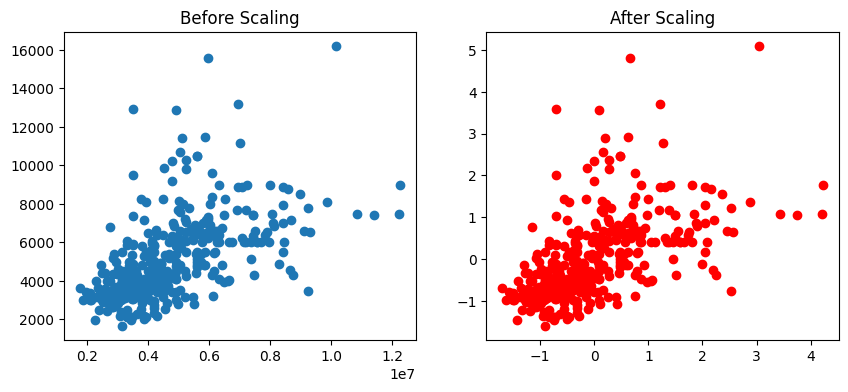

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

ax1.scatter(X_train['price'], X_train['area'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_s['price'], X_train_s['area'],color='red')
ax2.set_title("After Scaling")
plt.show()

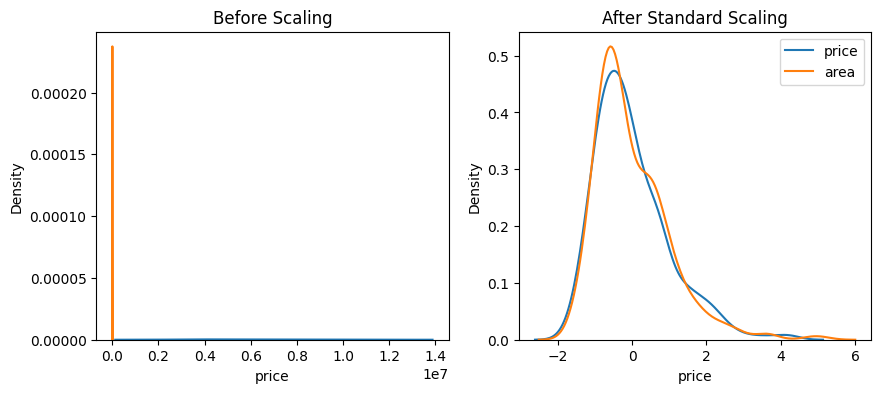

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['price'],label='price', ax=ax1)
sns.kdeplot(X_train['area'],label='area', ax=ax1)
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_s['price'],label='price', ax=ax2)
sns.kdeplot(X_train_s['area'], label='area',ax=ax2)
plt.legend()
plt.show()

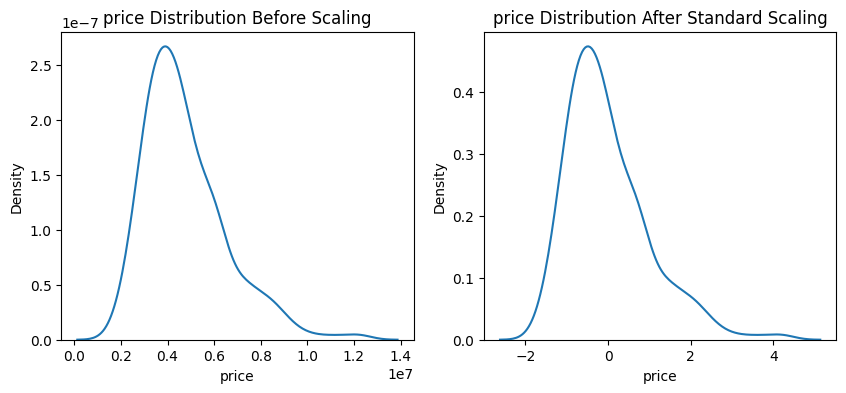

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

# before scaling
ax1.set_title('price Distribution Before Scaling')
sns.kdeplot(X_train['price'], ax=ax1)

# after scaling
ax2.set_title('price Distribution After Standard Scaling')
sns.kdeplot(X_train_s['price'], ax=ax2)
plt.show()

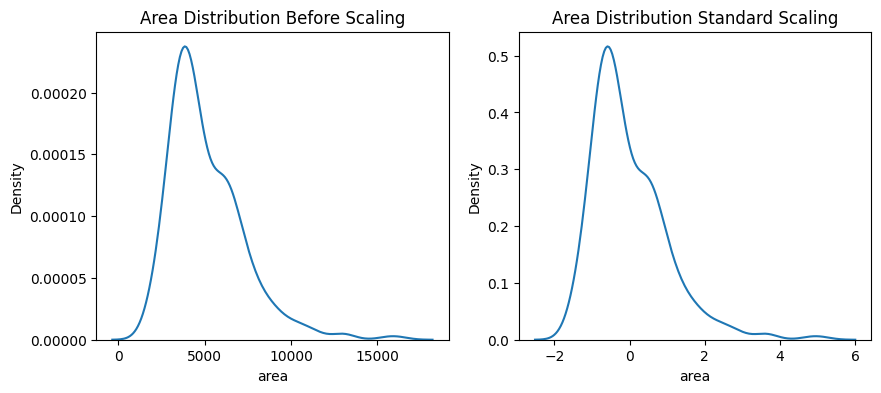

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

# before scaling
ax1.set_title('Area Distribution Before Scaling')
sns.kdeplot(X_train['area'], ax=ax1)

# after scaling
ax2.set_title('Area Distribution Standard Scaling')
sns.kdeplot(X_train_s['area'], ax=ax2)
plt.show()

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
lr = LogisticRegression()
lr_s = LogisticRegression()


In [38]:
lr.fit(X_train,y_train)
lr_s.fit(X_train_s,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_s.predict(X_test_s)
from sklearn.metrics import accuracy_score

In [40]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.6890243902439024
Scaled 0.6402439024390244


In [ ]:
outlier_df = pd.DataFrame({'price':[500,9870,995],'area':[441000,250000,350000],'Purchased':[0,1,1]})

In [42]:
new_df = pd.concat([df,outlier_df],ignore_index=True)
new_df

,price,area,Purchased
0,13300000,7420,0
1,12250000,8960,0
2,12250000,9960,0
3,12215000,7500,0
4,11410000,7420,1
...,...,...,...
543,1750000,2910,1
544,1750000,3850,1
545,500,441000,0
546,9870,250000,1


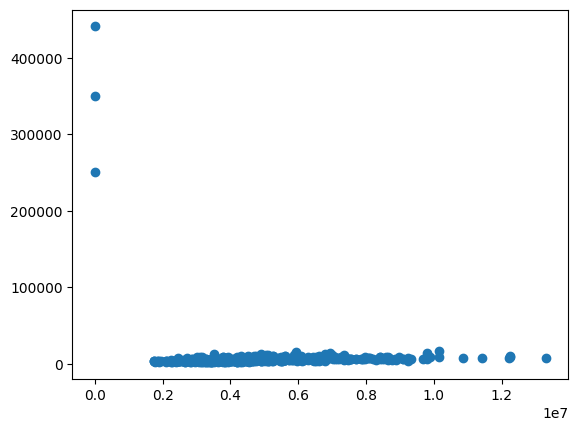

In [43]:
plt.scatter(new_df['price'], new_df['area'])

In [44]:
from sklearn.model_selection import train_test_split
new_x = new_df.drop('Purchased', axis=1)
new_y = new_df['Purchased']
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_x,new_y,test_size=0.3,random_state=0)

new_X_train.shape, new_X_test.shape


((383, 2), (165, 2))

In [45]:
from sklearn.preprocessing import StandardScaler

new_ss = StandardScaler()

# fit the ss to the train set, it will learn the parameters
new_ss.fit(new_X_train)

# transform train and test sets
new_X_train_s = new_ss.transform(new_X_train)
new_X_test_s = new_ss.transform(new_X_test)

In [46]:
new_X_train_s = pd.DataFrame(new_X_train_s, columns=X_train.columns)
new_X_test_s = pd.DataFrame(new_X_test_s, columns=X_test.columns)

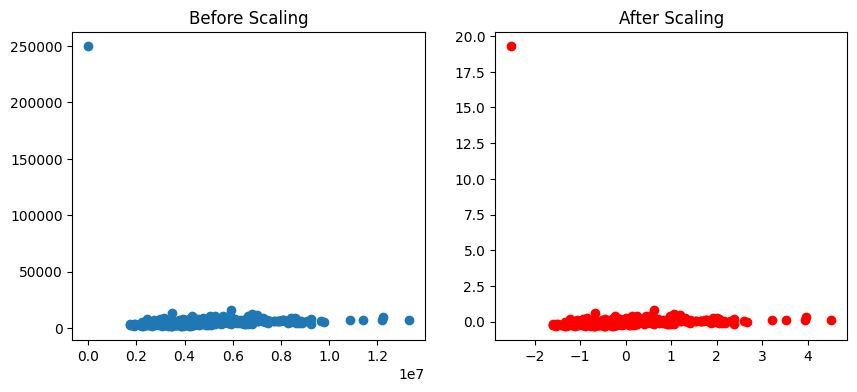

In [47]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

ax1.scatter(new_X_train['price'], new_X_train['area'])
ax1.set_title("Before Scaling")
ax2.scatter(new_X_train_s['price'], new_X_train_s['area'],color='red')
ax2.set_title("After Scaling")
plt.show()